# Tahap 2: Pemrograman Model JST Backpropagation

Pada tahap ini, kita membangun model JST untuk memprediksi harga beras menggunakan algoritma Backpropagation
1. Normalisasi data (MinMaxScaler).
2. Pemisahan data training dan testing.
3. Inisialisasi dan training model JST.
4. Hyperparameter tuning untuk optimalisasi.

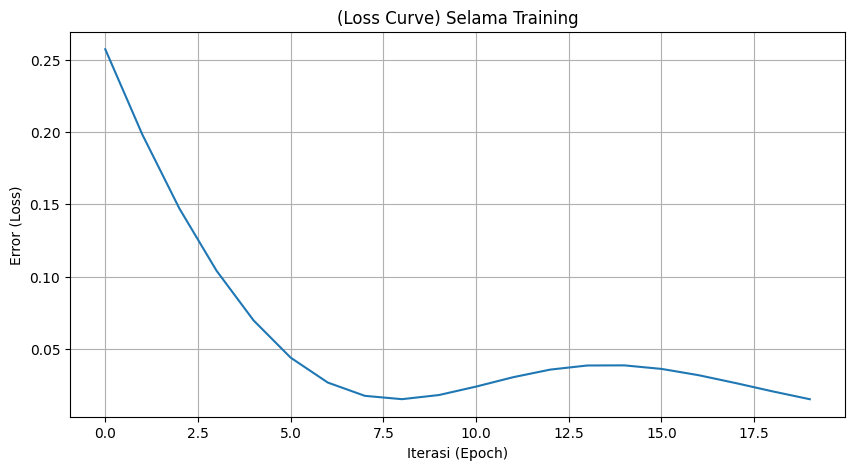

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 1. Load Data Preprocessed
df = pd.read_csv('beras_medium_monthly.csv')

# Menentukan Fitur (X) dan Target (y)
X = df[['lag_1', 'lag_2']].values
y = df['jumlah'].values.reshape(-1, 1)

# 2. Normalisasi Data
scaler_X = MinMaxScaler(feature_range=(0, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1))

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

# 3. Split Data (Training & Testing)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42, shuffle=False)

# 4. Inisialisasi Model JST Backpropagation
model = MLPRegressor(
    hidden_layer_sizes=(8, 4), 
    activation='tanh', 
    solver='adam', 
    max_iter=1000, 
    learning_rate_init=0.01, 
    random_state=42
)

# 5. Proses Training
model.fit(X_train, y_train.ravel())

# 6. Visualisasi Loss Curve (Proses Belajar)
plt.figure(figsize=(10,5))
plt.plot(model.loss_curve_)
plt.title('(Loss Curve) Selama Training')
plt.xlabel('Iterasi (Epoch)')
plt.ylabel('Error (Loss)')
plt.grid(True)
plt.show()

# Simpan data loss curve untuk dashboard
df_loss = pd.DataFrame({'loss': model.loss_curve_})
df_loss.to_csv('loss_curve.csv', index=False)


### Pengujian & Hyperparameter Tuning

RMSE pada Data Testing: 286.07


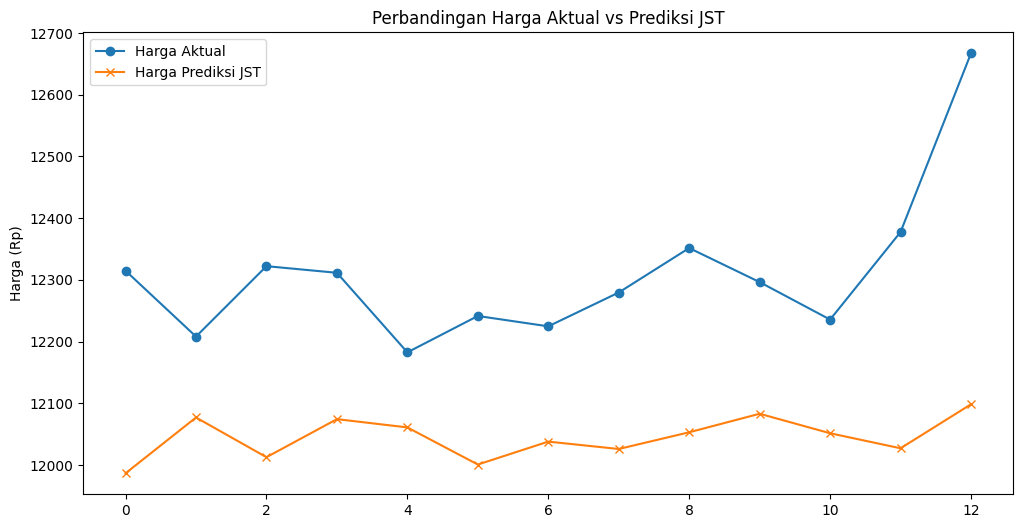

In [6]:
# Mencoba prediksi pada data test
y_pred_scaled = model.predict(X_test)

# Denormalisasi (Mengembalikan nilai 0-1 ke harga asli Rp)
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1))
y_actual = scaler_y.inverse_transform(y_test)

# Hitung Error Sederhana
rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
print(f"RMSE pada Data Testing: {rmse:.2f}")

# Visualisasi Hasil Prediksi vs Aktual
plt.figure(figsize=(12,6))
plt.plot(y_actual, label='Harga Aktual', marker='o')
plt.plot(y_pred, label='Harga Prediksi JST', marker='x')
plt.title('Perbandingan Harga Aktual vs Prediksi JST')
plt.ylabel('Harga (Rp)')
plt.legend()
plt.show()

# Simpan hasil prediksi untuk tahap evaluasi di notebook terpisah
df_results = pd.DataFrame({
    'actual': y_actual.flatten(),
    'prediction': y_pred.flatten()
})
df_results.to_csv('prediction_results.csv', index=False)